# UCSD Enrollment Growth and Rents in Nearby ZIP Codes
## San Diego County ZIP-Month Panel Analysis, 2015-2024

**MATH 189 Course Project**

This notebook builds the analysis panel and runs the statistical analysis.

Raw data were downloaded and cleaned by four preparation scripts:

| Script | Purpose | Source |
|---|---|---|
| `01_zillow_setup.py` | SD County rent panel | Zillow Research (ZORI) |
| `02_acs_pull.py` | Demographic controls | U.S. Census Bureau ACS 5-Year API |
| `03_build_ipeds_enrollment.py` | UCSD enrollment | NCES IPEDS Fall Enrollment files |
| `04_control_selection.py` | Matched control ZIPs | U.S. Census Gazetteer + ACS |

All values come from public official sources. No data are simulated, estimated, or imputed by hand.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option("display.max_columns", None)
print("pandas", pd.__version__)

pandas 2.2.3


## 2. Load Prepared Data

We load the four cleaned data files produced by the preparation scripts.

- `zori_sd_long.csv` &mdash; monthly rent index (ZORI) for San Diego County ZIP codes, long format (one row per ZIP-month).
- `ucsd_enrollment.csv` &mdash; UCSD total Fall enrollment by year (IPEDS).
- `acs_sd_panel.csv` &mdash; ACS demographic and housing variables by ZIP and ACS 5-year vintage.
- `control_zips.csv` &mdash; the 16 matched control ZIP codes selected in `04_control_selection.py`.

In [2]:
zori = pd.read_csv("data/zori_sd_long.csv")
enroll = pd.read_csv("data/ucsd_enrollment.csv")
acs = pd.read_csv("data/acs_sd_panel.csv")
controls = pd.read_csv("data/control_zips.csv")

print("zori_sd_long.csv  :", zori.shape)
print("ucsd_enrollment   :", enroll.shape)
print("acs_sd_panel.csv  :", acs.shape)
print("control_zips.csv  :", controls.shape)

zori_sd_long.csv  : (5041, 13)
ucsd_enrollment   : (15, 5)
acs_sd_panel.csv  : (160, 8)
control_zips.csv  : (16, 6)


## 3. Define the Analysis Sample

The analysis sample consists of **3 treated ZIP codes** (UCSD-adjacent student rental areas) and **16 matched control ZIP codes** (selected in `04_control_selection.py` as the San Diego County ZIPs more than 10 miles from campus whose baseline characteristics are closest to the treated group).

| Treated ZIP | Neighborhood |
|---|---|
| 92037 | La Jolla |
| 92122 | University City / UTC |
| 92126 | Mira Mesa |

Note: ZIP 92121 (Sorrento Valley) was listed in the proposal but is excluded here because Zillow ZORI publishes rent data for only 2 of 136 months for that ZIP, reflecting its predominantly commercial/biotech land use.

In [3]:
TREATED_ZIPS = [92122, 92037, 92126]
CONTROL_ZIPS = controls["zip"].astype(int).tolist()
ANALYSIS_ZIPS = TREATED_ZIPS + CONTROL_ZIPS

print(f"Treated ZIPs ({len(TREATED_ZIPS)}):", sorted(TREATED_ZIPS))
print(f"Control ZIPs ({len(CONTROL_ZIPS)}):", sorted(CONTROL_ZIPS))
print(f"Total analysis ZIPs: {len(ANALYSIS_ZIPS)}")

Treated ZIPs (3): [92037, 92122, 92126]
Control ZIPs (16): [91910, 91911, 91913, 91942, 92008, 92011, 92020, 92024, 92054, 92056, 92057, 92069, 92071, 92078, 92118, 92128]
Total analysis ZIPs: 19


## 4. Build the ZIP-Month Panel

The unit of observation is the **ZIP-month**. We combine three data sources of different time frequency into one panel:

1. **Rent (monthly).** Start from `zori_sd_long.csv`, keep the 19 analysis ZIPs, and restrict to January 2015 - December 2024 (the period stated in the proposal; ZORI begins in 2015 and IPEDS enrollment is available through 2024).
2. **UCSD enrollment (annual).** Merged on calendar year, so every month in a given year receives that year's Fall enrollment figure.
3. **ACS controls (5-year estimates).** ACS publishes 5-year estimates; we have vintages 2017, 2019, 2021, and 2023. Each panel year is matched to the **nearest** available ACS vintage. This is a transparent rule; no values are interpolated by hand.

We then add the treatment indicator and log transforms used in the regression.

In [4]:
# Step 1: rent, restricted to analysis ZIPs and 2015-2024
panel = zori[zori["zip"].isin(ANALYSIS_ZIPS)].copy()
panel["month"] = pd.to_datetime(panel["month"])
panel["year"] = panel["month"].dt.year
panel = panel[(panel["year"] >= 2015) & (panel["year"] <= 2024)].copy()

# Step 2: merge UCSD annual enrollment (broadcast to all months in the year)
panel = panel.merge(enroll[["year", "total_enrollment"]], on="year", how="left")

# Step 3: merge ACS controls using the nearest available ACS vintage
acs_years = sorted(acs["acs_year"].unique())
panel["acs_year"] = panel["year"].apply(
    lambda y: min(acs_years, key=lambda a: abs(a - y)))
panel = panel.merge(
    acs[["zip", "acs_year", "median_income", "renter_share", "population"]],
    on=["zip", "acs_year"], how="left")

# Step 4: treatment indicator and transformed variables
panel["treated"] = panel["zip"].isin(TREATED_ZIPS).astype(int)
panel["log_rent"] = np.log(panel["zori"])
panel["log_enrollment"] = np.log(panel["total_enrollment"])
panel["log_income"] = np.log(panel["median_income"])

panel = panel.sort_values(["zip", "month"]).reset_index(drop=True)
print("Panel shape:", panel.shape)
panel[["zip", "month", "year", "zori", "log_rent", "treated",
       "total_enrollment", "median_income", "renter_share"]].head()

Panel shape: (2080, 22)


,zip,month,year,zori,log_rent,treated,total_enrollment,median_income,renter_share
0,91910,2017-05-31,2017,1527.130255,7.331146,0,35772,59371,0.526581
1,91910,2017-06-30,2017,1521.436114,7.327410,0,35772,59371,0.526581
2,91910,2017-07-31,2017,1560.984212,7.353072,0,35772,59371,0.526581
3,91910,2017-08-31,2017,1568.382264,7.357800,0,35772,59371,0.526581
4,91910,2017-09-30,2017,1590.898261,7.372054,0,35772,59371,0.526581


## 5. Verify the Panel

Before using the panel we run three checks:

1. **Coverage** &mdash; number of ZIPs, month range, treated vs control counts.
2. **Missing values** &mdash; how many cells are missing in each column.
3. **Cross-check against the raw source** &mdash; pick one rent value and confirm it equals the value in the raw file, proving the merge did not alter any data.

In [5]:
# 1. Coverage
print("ZIPs in panel        :", panel["zip"].nunique())
print("Month range          :", panel["month"].min().date(),
      "to", panel["month"].max().date())
print("Treated ZIP-months   :", int((panel["treated"] == 1).sum()))
print("Control ZIP-months   :", int((panel["treated"] == 0).sum()))
print("Total rows           :", len(panel))

# 2. Missing values
print("\nMissing values per column:")
print(panel[["zori", "total_enrollment", "median_income",
             "renter_share", "population"]].isna().sum())

ZIPs in panel        : 19
Month range          : 2015-01-31 to 2024-12-31
Treated ZIP-months   : 360
Control ZIP-months   : 1720
Total rows           : 2080

Missing values per column:
zori                0
total_enrollment    0
median_income       0
renter_share        0
population          0
dtype: int64


In [6]:
# 3. Cross-check one rent value against the raw source file
raw = pd.read_csv("data/zori_sd_long.csv")
raw_val = raw[(raw["zip"] == 92122) &
              (raw["month"] == "2015-01-31")]["zori"].iloc[0]
panel_val = panel[(panel["zip"] == 92122) &
                  (panel["month"] == "2015-01-31")]["zori"].iloc[0]

print(f"ZIP 92122, Jan 2015 rent")
print(f"  raw source file : {raw_val:.6f}")
print(f"  analysis panel  : {panel_val:.6f}")
print(f"  identical       : {np.isclose(raw_val, panel_val)}")

ZIP 92122, Jan 2015 rent
  raw source file : 1733.489632
  analysis panel  : 1733.489632
  identical       : True


## 6. Save the Analysis Panel

The verified panel is saved to `data/analysis_panel.csv` for use in the exploratory analysis and regression sections.

In [7]:
panel.to_csv("data/analysis_panel.csv", index=False)
print("Saved: data/analysis_panel.csv", panel.shape)

Saved: data/analysis_panel.csv (2080, 22)


## 7. Exploratory Data Analysis

This section describes the data before any formal modeling. We look at the enrollment series, rent trends in treated versus control ZIP codes, pre-pandemic trend comparability, the spread of rent growth across ZIPs, baseline group differences, and panel coverage.

### 7.1 UCSD Enrollment Trend, 2010-2024

UCSD enrollment is the explanatory variable of interest. We plot the IPEDS Fall enrollment series to confirm the long-run upward trend described in the proposal.

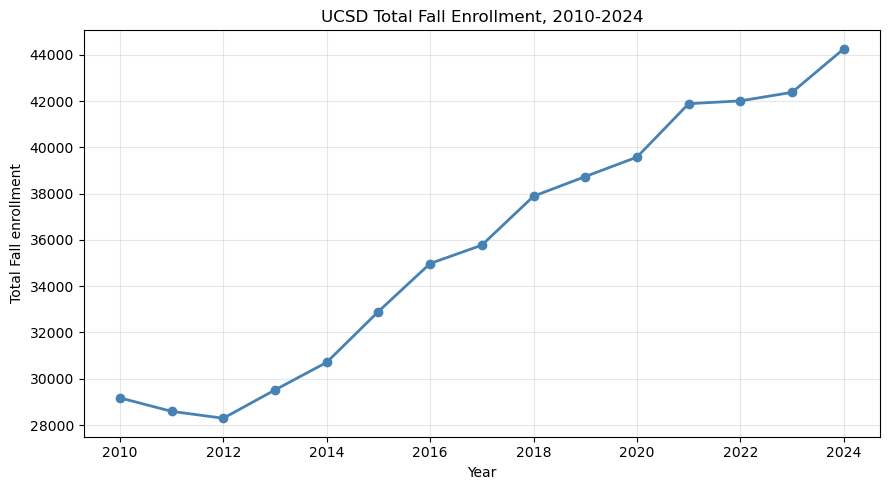

Enrollment 2010 : 29,176
Enrollment 2024 : 44,256
Total growth    : 51.7%


In [8]:
# Reload the saved panel so this section can run independently
panel = pd.read_csv("data/analysis_panel.csv", parse_dates=["month"])
enroll = pd.read_csv("data/ucsd_enrollment.csv")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(enroll["year"], enroll["total_enrollment"],
        marker="o", color="steelblue", linewidth=2)
ax.set_title("UCSD Total Fall Enrollment, 2010-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Total Fall enrollment")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/02_enrollment_trend.png", dpi=150)
plt.show()

g = enroll["total_enrollment"].iloc[-1] / enroll["total_enrollment"].iloc[0] - 1
print(f"Enrollment 2010 : {enroll['total_enrollment'].iloc[0]:,}")
print(f"Enrollment 2024 : {enroll['total_enrollment'].iloc[-1]:,}")
print(f"Total growth    : {g*100:.1f}%")

### 7.2 Rent Trends: Treated vs Control ZIP Codes

We plot the mean monthly rent (ZORI) separately for the 3 treated and 16 control ZIP codes. Treated ZIPs are expected to sit at a higher rent level (they are closer to the coast and to campus); the question of interest is whether the **gap widens** over the period, not whether the levels differ.

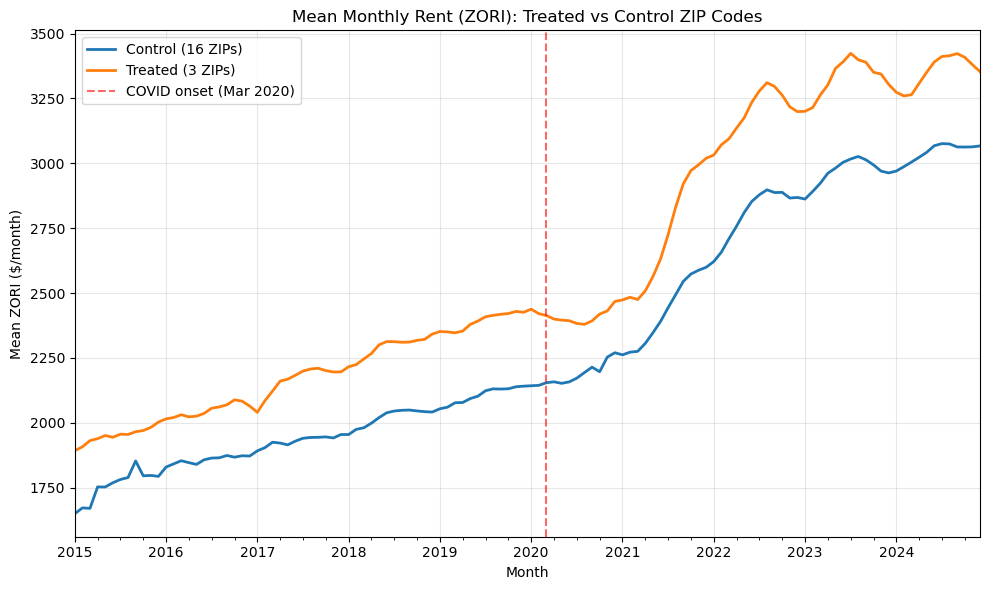

In [9]:
agg = panel.groupby(["month", "treated"])["zori"].mean().unstack()
agg.columns = ["Control (16 ZIPs)", "Treated (3 ZIPs)"]

fig, ax = plt.subplots(figsize=(10, 6))
agg.plot(ax=ax, linewidth=2)
ax.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--",
           alpha=0.6, label="COVID onset (Mar 2020)")
ax.set_title("Mean Monthly Rent (ZORI): Treated vs Control ZIP Codes")
ax.set_xlabel("Month")
ax.set_ylabel("Mean ZORI ($/month)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/03_rent_treated_vs_control.png", dpi=150)
plt.show()

### 7.3 Pre-Pandemic Trend Comparison (2015-2019)

A difference-in-differences style comparison is most credible when treated and control groups followed similar trends before the period of interest. Because UCSD enrollment grew gradually (there is no single sharp treatment date), we do **not** run a formal parallel-trends test. Instead we compare the **average annual log-rent growth rate** of the two groups during the pre-pandemic window 2015-2019.

We also index both series to 100 at January 2015 so that growth rates (not levels) are directly visible.

Pre-pandemic (2015-2019) mean annual log-rent growth:
  Treated : 5.21% per year
  Control : 4.26% per year
  Difference (Treated - Control): 0.96 percentage points per year


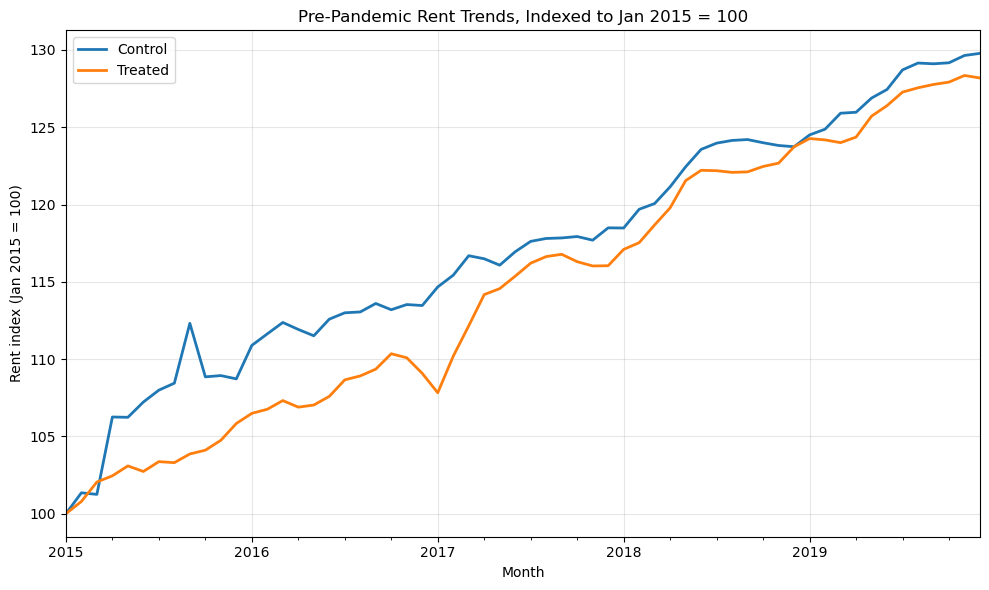

In [10]:
pre = panel[panel["year"] <= 2019].copy()
pre["t_years"] = (pre["month"] - pd.Timestamp("2015-01-01")).dt.days / 365.25

print("Pre-pandemic (2015-2019) mean annual log-rent growth:")
slopes = {}
for grp, name in [(1, "Treated"), (0, "Control")]:
    sub = pre[pre["treated"] == grp]
    m = sub.groupby("t_years")["log_rent"].mean().reset_index()
    slope, _ = np.polyfit(m["t_years"], m["log_rent"], 1)
    slopes[name] = slope
    print(f"  {name:<8}: {slope*100:.2f}% per year")
diff = (slopes["Treated"] - slopes["Control"]) * 100
print(f"  Difference (Treated - Control): {diff:.2f} percentage points per year")

# Indexed plot (Jan 2015 = 100)
pre_agg = pre.groupby(["month", "treated"])["zori"].mean().unstack()
pre_idx = pre_agg / pre_agg.iloc[0] * 100
pre_idx.columns = ["Control", "Treated"]

fig, ax = plt.subplots(figsize=(10, 6))
pre_idx.plot(ax=ax, linewidth=2)
ax.set_title("Pre-Pandemic Rent Trends, Indexed to Jan 2015 = 100")
ax.set_xlabel("Month")
ax.set_ylabel("Rent index (Jan 2015 = 100)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/04_pre_pandemic_trends.png", dpi=150)
plt.show()

### 7.4 Total Rent Growth by ZIP Code, 2015-2024

We compute each ZIP's total rent growth from its first to its last observed month in the panel. Because ZORI coverage begins at different dates for some control ZIPs, the windows are not identical across ZIPs; this chart is descriptive only and the regression below uses the full monthly panel rather than these endpoint growth rates.

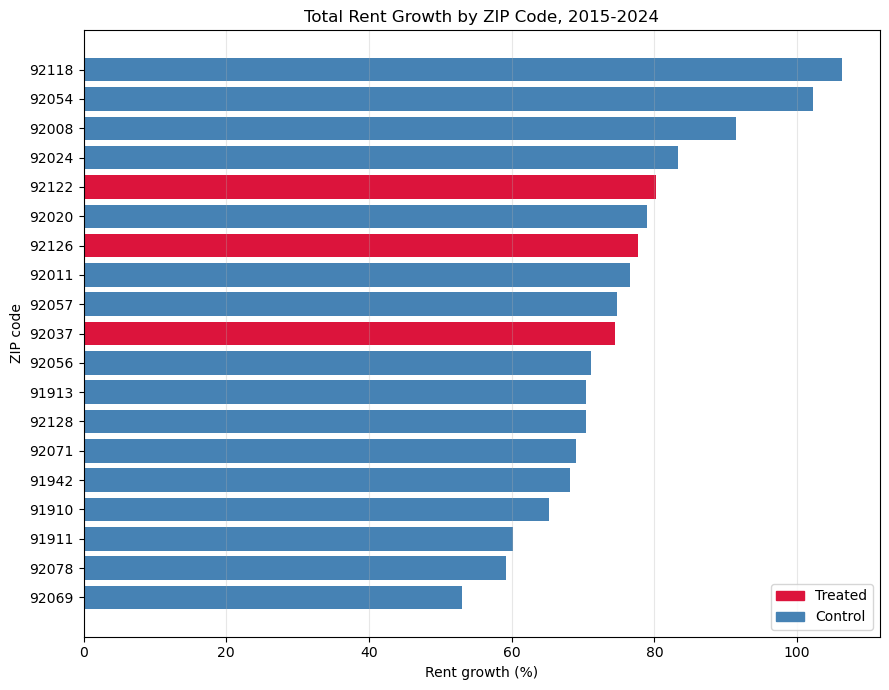

Mean rent growth:
  Treated: 77.5%
  Control: 75.0%


In [11]:
rows = []
for z, sub in panel.groupby("zip"):
    sub = sub.sort_values("month")
    growth = sub["zori"].iloc[-1] / sub["zori"].iloc[0] - 1
    rows.append({"zip": z, "growth": growth * 100,
                 "treated": sub["treated"].iloc[0]})
gdf = pd.DataFrame(rows).sort_values("growth")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["crimson" if t == 1 else "steelblue" for t in gdf["treated"]]
ax.barh(gdf["zip"].astype(str), gdf["growth"], color=colors)
ax.set_title("Total Rent Growth by ZIP Code, 2015-2024")
ax.set_xlabel("Rent growth (%)")
ax.set_ylabel("ZIP code")
ax.legend(handles=[Patch(color="crimson", label="Treated"),
                   Patch(color="steelblue", label="Control")])
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig("figures/05_rent_growth_by_zip.png", dpi=150)
plt.show()

print("Mean rent growth:")
print(f"  Treated: {gdf[gdf.treated==1]['growth'].mean():.1f}%")
print(f"  Control: {gdf[gdf.treated==0]['growth'].mean():.1f}%")

### 7.5 Baseline Characteristics: Treated vs Control

We summarize how the two groups differ on observable characteristics. As discussed in the control-selection step, treated ZIPs are denser and higher-income; ZIP fixed effects in the regression absorb these time-invariant level differences.

In [12]:
geo = pd.read_csv("data/zip_geo.csv")

base_rent = (panel[panel["year"] == 2015]
             .groupby("zip")["zori"].mean().rename("rent_2015"))
base = panel.groupby("zip").agg(
    treated=("treated", "first"),
    median_income=("median_income", "first"),
    renter_share=("renter_share", "first")).reset_index()
base = base.merge(base_rent, on="zip", how="left")
base = base.merge(geo[["zip", "dist_to_ucsd", "pop_density"]],
                  on="zip", how="left")

summary = base.groupby("treated").agg(
    n_zips=("zip", "count"),
    rent_2015=("rent_2015", "mean"),
    median_income=("median_income", "mean"),
    renter_share=("renter_share", "mean"),
    pop_density=("pop_density", "mean"),
    dist_to_ucsd=("dist_to_ucsd", "mean")).T
summary.columns = ["Control", "Treated"]
print("Baseline characteristics (group means):")
print(summary.round(2))

Baseline characteristics (group means):
                Control   Treated
n_zips            16.00      3.00
rent_2015       1773.97   1950.05
median_income  75781.25  92009.00
renter_share       0.44      0.51
pop_density     4352.71   6393.33
dist_to_ucsd      18.09      3.29


### 7.6 Panel Coverage

Finally we check how many monthly observations each ZIP contributes. All three treated ZIPs have the full 120 months; some control ZIPs start later because ZORI coverage begins at different dates. The panel is therefore **unbalanced**, which the fixed-effects estimator accommodates.

In [13]:
coverage = panel.groupby("zip").agg(
    months=("month", "size"),
    treated=("treated", "first")).sort_values("months")
print("Months of data per ZIP (out of 120 possible):\n")
for z, r in coverage.iterrows():
    tag = "TREATED" if r["treated"] == 1 else "control"
    print(f"  {z} [{tag}]: {int(r['months'])}")
print(f"\nMean coverage: {coverage['months'].mean():.0f} months")

Months of data per ZIP (out of 120 possible):

  92069 [control]: 84
  91910 [control]: 92
  91911 [control]: 93
  92020 [control]: 104
  92024 [control]: 104
  92118 [control]: 105
  91942 [control]: 105
  92071 [control]: 105
  92056 [control]: 105
  92078 [control]: 108
  92011 [control]: 116
  92054 [control]: 119
  92126 [TREATED]: 120
  92037 [TREATED]: 120
  92008 [control]: 120
  91913 [control]: 120
  92122 [TREATED]: 120
  92057 [control]: 120
  92128 [control]: 120

Mean coverage: 109 months


## 8. Main Regression

We estimate a two-way fixed-effects panel regression:

log(Rent_zt) = beta * (Treated_z * log(Enrollment_t)) + alpha_z + gamma_t + theta * log(Income_zt) + e_zt

where z indexes ZIP codes and t indexes months.

- alpha_z (ZIP fixed effects) absorb time-invariant ZIP characteristics, including the standalone Treated indicator and level differences in income, density, and coastal proximity.
- gamma_t (month fixed effects) absorb everything common to all San Diego ZIPs in a given month, including interest rates, regional housing trends, COVID shocks, and the standalone level of UCSD enrollment.
- log(Income_zt) is a time-varying demographic control.
- beta is the coefficient of interest. Because the standalone Treated and log(Enrollment) terms are collinear with the fixed effects, only their interaction is estimable. beta measures whether rents in treated ZIPs rise differentially with UCSD enrollment, relative to control ZIPs in the same month.

Standard errors are clustered at the ZIP level (19 clusters). We note that 19 clusters is small for cluster-robust inference; Section 9 addresses this with a wild cluster bootstrap.

**Hypothesis test (one-sided):**
- H0: beta = 0  (no differential rent response)
- H1: beta > 0  (treated ZIP rents rise more with enrollment)

In [14]:
import statsmodels.formula.api as smf

reg = panel.copy()
reg["interaction"] = reg["treated"] * reg["log_enrollment"]

model = smf.ols(
    "log_rent ~ interaction + C(zip) + C(month) + log_income",
    data=reg
).fit(cov_type="cluster", cov_kwds={"groups": reg["zip"]})

beta = model.params["interaction"]
se = model.bse["interaction"]
ci_low, ci_high = model.conf_int().loc["interaction"]
p_two = model.pvalues["interaction"]
p_one = p_two / 2 if beta > 0 else 1 - p_two / 2

print("Main regression: interaction coefficient (Treated x log Enrollment)")
print(f"  beta (point estimate) : {beta:.4f}")
print(f"  cluster-robust SE     : {se:.4f}")
print(f"  95% CI                : [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  two-sided p-value     : {p_two:.4f}")
print(f"  one-sided p-value     : {p_one:.4f}")
print(f"  N observations        : {int(model.nobs)}")
print(f"  R-squared             : {model.rsquared:.4f}")

Main regression: interaction coefficient (Treated x log Enrollment)
  beta (point estimate) : -0.1129
  cluster-robust SE     : 0.0681
  95% CI                : [-0.2465, 0.0206]
  two-sided p-value     : 0.0974
  one-sided p-value     : 0.9513
  N observations        : 2080
  R-squared             : 0.9931


In [15]:
# Estimable coefficients other than the ZIP and month fixed effects
keep = [c for c in model.params.index
        if not c.startswith("C(zip)") and not c.startswith("C(month)")]
coef_table = pd.DataFrame({
    "coef": model.params[keep],
    "std_err": model.bse[keep],
    "ci_low": model.conf_int().loc[keep, 0],
    "ci_high": model.conf_int().loc[keep, 1],
    "p_value": model.pvalues[keep],
})
print("Non-fixed-effect coefficients:")
print(coef_table.round(4))

Non-fixed-effect coefficients:
               coef  std_err  ci_low  ci_high  p_value
Intercept    8.6960   0.7992  7.1296  10.2624   0.0000
interaction -0.1129   0.0681 -0.2465   0.0206   0.0974
log_income  -0.1337   0.0726 -0.2760   0.0086   0.0655


In [16]:
# Translate beta into an interpretable magnitude over the study period
e2015 = enroll.loc[enroll["year"] == 2015, "total_enrollment"].iloc[0]
e2024 = enroll.loc[enroll["year"] == 2024, "total_enrollment"].iloc[0]
dlog = np.log(e2024 / e2015)

print(f"UCSD enrollment 2015 -> 2024 : {e2015:,} -> {e2024:,} "
      f"({(e2024/e2015-1)*100:.1f}% increase)")
print(f"Change in log enrollment     : {dlog:.4f}")
print()
print("Implied differential rent effect, treated vs control, 2015-2024:")
print(f"  point estimate : {beta*dlog*100:+.1f}%")
print(f"  95% CI         : [{ci_low*dlog*100:+.1f}%, {ci_high*dlog*100:+.1f}%]")

UCSD enrollment 2015 -> 2024 : 32,906 -> 44,256 (34.5% increase)
Change in log enrollment     : 0.2963

Implied differential rent effect, treated vs control, 2015-2024:
  point estimate : -3.3%
  95% CI         : [-7.3%, +0.6%]


## 9. Robustness Checks

The main estimate relies on several modeling choices: the cluster-robust standard error (with only 19 clusters), the 3 treated ZIPs, the 16 matched controls, and the 2015-2024 window. This section checks whether the interaction coefficient is stable across reasonable alternatives.

We define two helper functions so that every robustness check uses exactly the same panel-construction and estimation logic as the main specification.

In [17]:
import statsmodels.api as sm

# Reload source data so this section is self-contained
zori = pd.read_csv("data/zori_sd_long.csv")
enroll = pd.read_csv("data/ucsd_enrollment.csv")
acs = pd.read_csv("data/acs_sd_panel.csv")
geo = pd.read_csv("data/zip_geo.csv")
acs_years = sorted(acs["acs_year"].unique())


def build_panel(treated_zips, control_zips, year_min=2015, year_max=2024):
    """Build a ZIP-month analysis panel for a given treated/control split."""
    zips = list(treated_zips) + list(control_zips)
    p = zori[zori["zip"].isin(zips)].copy()
    p["month"] = pd.to_datetime(p["month"])
    p["year"] = p["month"].dt.year
    p = p[(p["year"] >= year_min) & (p["year"] <= year_max)].copy()
    p = p.merge(enroll[["year", "total_enrollment"]], on="year", how="left")
    p["acs_year"] = p["year"].apply(
        lambda y: min(acs_years, key=lambda a: abs(a - y)))
    p = p.merge(acs[["zip", "acs_year", "median_income"]],
                on=["zip", "acs_year"], how="left")
    p["treated"] = p["zip"].isin(treated_zips).astype(int)
    p["log_rent"] = np.log(p["zori"])
    p["log_enrollment"] = np.log(p["total_enrollment"])
    p["log_income"] = np.log(p["median_income"])
    p["interaction"] = p["treated"] * p["log_enrollment"]
    return p


def run_twfe(p):
    """Run the main two-way FE spec; return interaction-coefficient stats."""
    m = smf.ols("log_rent ~ interaction + C(zip) + C(month) + log_income",
                data=p).fit(cov_type="cluster", cov_kwds={"groups": p["zip"]})
    lo, hi = m.conf_int().loc["interaction"]
    return {"beta": m.params["interaction"], "se": m.bse["interaction"],
            "ci_low": lo, "ci_high": hi, "p_value": m.pvalues["interaction"],
            "n_obs": int(m.nobs), "n_zip": p["zip"].nunique()}


# Verify the helper reproduces the Section 8 main result
main = run_twfe(build_panel(TREATED_ZIPS, CONTROL_ZIPS))
print("Main spec via helper (should match Section 8):")
print(f"  beta = {main['beta']:.4f}, SE = {main['se']:.4f}, "
      f"p = {main['p_value']:.4f}, N = {main['n_obs']}")

Main spec via helper (should match Section 8):
  beta = -0.1129, SE = 0.0681, p = 0.0974, N = 2080


### 9.1 Wild Cluster Bootstrap

With only 19 clusters, the conventional cluster-robust standard error can be unreliable and tends to over-reject the null. The **wild cluster bootstrap** (Cameron, Gelbach & Miller, 2008) is the standard remedy for few-cluster settings.

We use the restricted (impose-the-null) version: we estimate the model with the interaction term removed, then in each bootstrap replication multiply each cluster's residuals by a random +1 or -1 weight, regenerate the outcome, refit the full model, and record the cluster-robust t-statistic. The bootstrap p-value is the share of replications whose |t| exceeds the observed |t|.

In [18]:
def wild_cluster_bootstrap(p, n_boot=999, seed=42):
    """Wild cluster bootstrap-t p-value for H0: interaction coefficient = 0.

    Implements the restricted (impose-the-null) wild cluster bootstrap of
    Cameron, Gelbach & Miller (2008) with Rademacher (+1/-1) cluster weights.
    Designed for settings with few clusters, where the usual cluster-robust
    standard error can be unreliable.
    """
    full = smf.ols("log_rent ~ interaction + C(zip) + C(month) + log_income",
                   data=p).fit(cov_type="cluster",
                               cov_kwds={"groups": p["zip"]})
    names = list(full.model.exog_names)
    j = names.index("interaction")
    X = full.model.exog
    y = full.model.endog
    groups = p["zip"].values
    t_obs = full.params.iloc[j] / full.bse.iloc[j]

    # Restricted model: drop the interaction column to impose H0
    X_r = np.delete(X, j, axis=1)
    restr = sm.OLS(y, X_r).fit()
    fitted_r = restr.fittedvalues
    resid_r = restr.resid

    rng = np.random.default_rng(seed)
    uniq = np.unique(groups)
    t_boot = np.empty(n_boot)
    for b in range(n_boot):
        w = rng.choice([-1.0, 1.0], size=len(uniq))
        wmap = dict(zip(uniq, w))
        wv = np.array([wmap[g] for g in groups])
        y_star = fitted_r + resid_r * wv
        fb = sm.OLS(y_star, X).fit(cov_type="cluster",
                                   cov_kwds={"groups": groups})
        t_boot[b] = fb.params[j] / fb.bse[j]
    p_val = np.mean(np.abs(t_boot) >= np.abs(t_obs))
    return t_obs, p_val

t_obs, p_wild = wild_cluster_bootstrap(
    build_panel(TREATED_ZIPS, CONTROL_ZIPS), n_boot=999)
print("Wild cluster bootstrap (999 reps, H0: interaction = 0)")
print(f"  observed cluster-robust t : {t_obs:.4f}")
print(f"  bootstrap two-sided p     : {p_wild:.4f}")

Wild cluster bootstrap (999 reps, H0: interaction = 0)
  observed cluster-robust t : -1.6574
  bootstrap two-sided p     : 0.1491


### 9.2 Robustness Checks 2-5

We rerun the main specification under four alternative choices:

- **Leave-one-treated-out.** Drop each of the 3 treated ZIPs in turn. Because there are only 3 treated units, this checks whether the result is driven by any single ZIP.
- **Expanded control.** Use all San Diego analysis ZIPs more than 10 miles from UCSD as controls, instead of the 16 nearest matches.
- **Expanded treated.** Add Clairemont (92117) and Pacific Beach (92109), which are closer to campus but more affected by tourism and lifestyle demand.
- **Pre-COVID only.** Restrict the sample to 2015-2019, removing the pandemic-era housing shock.

In [19]:
# Run robustness checks 2-5 and collect into one table
results = {"Main (3 treated, 16 control)": main}

# R2: Leave-one-treated-out -- drop each treated ZIP in turn
for drop_zip in TREATED_ZIPS:
    keep_t = [z for z in TREATED_ZIPS if z != drop_zip]
    results[f"Drop treated {drop_zip}"] = run_twfe(
        build_panel(keep_t, CONTROL_ZIPS))

# R3: Expanded control -- all SD analysis ZIPs >10 mi from UCSD, not treated
exp_controls = geo[(geo["treated"] == 0) &
                   (geo["dist_to_ucsd"] > 10)]["zip"].astype(int).tolist()
results[f"Expanded control ({len(exp_controls)} ctrl)"] = run_twfe(
    build_panel(TREATED_ZIPS, exp_controls))

# R4: Expanded treated -- add Clairemont (92117) and Pacific Beach (92109)
results["Expanded treated (5 treated)"] = run_twfe(
    build_panel(TREATED_ZIPS + [92117, 92109], CONTROL_ZIPS))

# R5: Pre-COVID only -- restrict to 2015-2019
results["Pre-COVID only (2015-2019)"] = run_twfe(
    build_panel(TREATED_ZIPS, CONTROL_ZIPS, year_max=2019))

robust = pd.DataFrame(results).T
robust["wild_p"] = ""
robust.loc["Main (3 treated, 16 control)", "wild_p"] = f"{p_wild:.4f}"
print("Robustness battery -- interaction coefficient across specifications:")
print(robust[["beta", "se", "ci_low", "ci_high", "p_value",
              "n_obs", "n_zip", "wild_p"]].round(4).to_string())

Robustness battery -- interaction coefficient across specifications:
                                beta      se  ci_low  ci_high  p_value   n_obs  n_zip  wild_p
Main (3 treated, 16 control) -0.1129  0.0681 -0.2465   0.0206   0.0974  2080.0   19.0  0.1491
Drop treated 92122           -0.1132  0.0739 -0.2581   0.0316   0.1256  1960.0   18.0        
Drop treated 92037           -0.1438  0.0670 -0.2751  -0.0126   0.0317  1960.0   18.0        
Drop treated 92126           -0.0852  0.0658 -0.2142   0.0439   0.1958  1960.0   18.0        
Expanded control (28 ctrl)   -0.0862  0.0589 -0.2016   0.0291   0.1428  3390.0   31.0        
Expanded treated (5 treated) -0.0217  0.0694 -0.1577   0.1142   0.7543  2297.0   21.0        
Pre-COVID only (2015-2019)   -0.0614  0.0931 -0.2439   0.1212   0.5099   941.0   19.0        


## 10. Event-Study Specification

The main regression in Section 8 summarizes the treated-control relationship in a single coefficient. A more flexible approach is an **event-study specification**, which estimates the treated-control rent gap separately for each year:

log(Rent_zt) = sum_k beta_k (Treated_z x Year_k) + alpha_z + gamma_t + theta log(Income_zt) + e_zt

Each beta_k is the average log-rent gap between treated and control ZIPs in year k, relative to the 2015 baseline year. Plotting these coefficients shows whether the gap widened, narrowed, or stayed flat over time. Because UCSD enrollment rose steadily across the period, a student-demand effect would appear as an upward-trending gap; a flat or non-monotone profile would indicate no such effect.

In [20]:
# Event-study: estimate the treated-control rent gap year by year.
# We build explicit treated x year interaction terms, omitting 2015 as the
# baseline year so that the 9 remaining terms are estimable.
es = panel.copy()
es["year"] = es["month"].dt.year

int_terms = []
for yr in range(2016, 2025):
    col = f"treated_x_{yr}"
    es[col] = es["treated"] * (es["year"] == yr).astype(int)
    int_terms.append(col)

formula = ("log_rent ~ " + " + ".join(int_terms)
           + " + C(zip) + C(month) + log_income")
es_model = smf.ols(formula, data=es).fit(
    cov_type="cluster", cov_kwds={"groups": es["zip"]})

# Collect the year-by-year coefficients (2015 = baseline = 0)
ci = es_model.conf_int()
es_rows = [{"year": 2015, "coef": 0.0, "ci_low": 0.0, "ci_high": 0.0}]
for yr in range(2016, 2025):
    col = f"treated_x_{yr}"
    es_rows.append({"year": yr,
                    "coef": es_model.params[col],
                    "ci_low": ci.loc[col, 0],
                    "ci_high": ci.loc[col, 1]})
es_df = pd.DataFrame(es_rows)
print("Event-study coefficients (treated-control log-rent gap vs 2015):")
print(es_df.round(4).to_string(index=False))

Event-study coefficients (treated-control log-rent gap vs 2015):
 year    coef  ci_low  ci_high
 2015  0.0000  0.0000   0.0000
 2016  0.0031 -0.0222   0.0285
 2017  0.0004 -0.0295   0.0302
 2018  0.0022 -0.0288   0.0332
 2019 -0.0077 -0.0399   0.0245
 2020 -0.0357 -0.0722   0.0008
 2021 -0.0215 -0.0539   0.0109
 2022 -0.0033 -0.0425   0.0358
 2023 -0.0197 -0.0540   0.0145
 2024 -0.0376 -0.0747  -0.0004


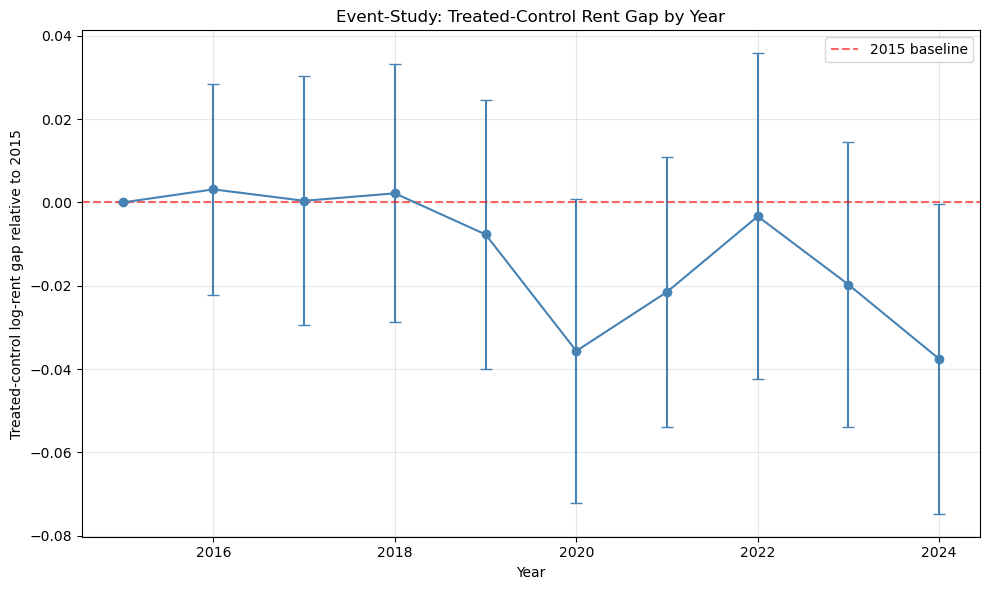

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(es_df["year"], es_df["coef"],
            yerr=[es_df["coef"] - es_df["ci_low"],
                  es_df["ci_high"] - es_df["coef"]],
            fmt="o-", color="steelblue", capsize=4)
ax.axhline(0, color="red", linestyle="--", alpha=0.6,
           label="2015 baseline")
ax.set_title("Event-Study: Treated-Control Rent Gap by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Treated-control log-rent gap relative to 2015")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/07_event_study.png", dpi=150)
plt.show()

### 10.1 Reading the Event-Study Plot

The event-study coefficients trace the treated-control log-rent gap relative to 2015:

- **2015-2018: the gap is essentially flat and statistically indistinguishable from zero** (all coefficients within +/-0.003, with confidence intervals covering zero). Treated and control ZIPs moved together during this period. This composition-adjusted result is reassuring for the design and gives a cleaner read than the raw group-mean comparison in Section 7.3, which did not adjust for the changing set of control ZIPs entering the panel over time.
- **2020-2024: the gap drifts modestly negative**, reaching about -0.04 by 2024 (treated ZIP rents roughly 4% below their 2015 relative position). Only the 2024 coefficient is marginally distinguishable from zero.

Crucially, the gap **never trends upward**. If UCSD's steadily rising enrollment were pushing up nearby rents, the event-study line would slope up over time. Instead it is flat through 2019 and then drifts down -- the opposite pattern, and one that coincides with the post-2020 period when remote work shifted rental demand toward suburban areas.

## 11. Results Summary and Conclusion

This section visualizes the robustness battery as a coefficient plot, then interprets the findings, states the limitations, and draws an overall conclusion.

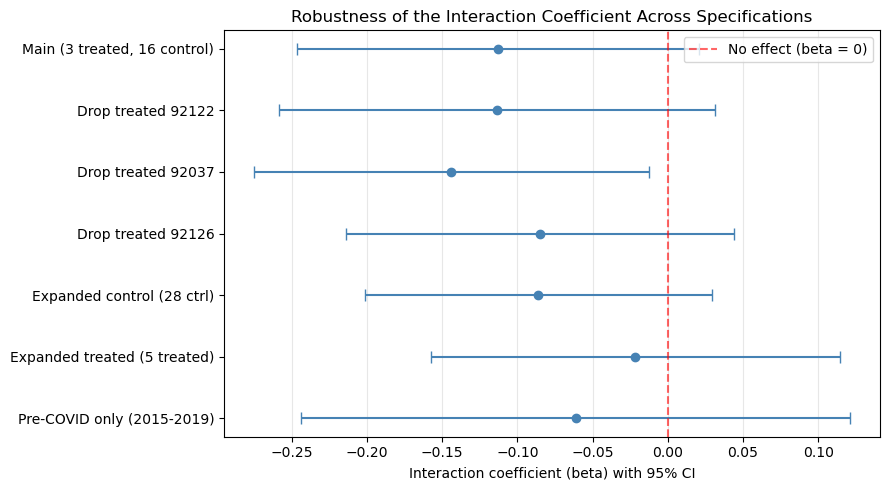

In [22]:
# Coefficient plot: interaction estimate with 95% CI across all specifications
specs = robust.index.tolist()
betas = robust["beta"].astype(float).values
los = robust["ci_low"].astype(float).values
his = robust["ci_high"].astype(float).values
ypos = np.arange(len(specs))

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(betas, ypos,
            xerr=[betas - los, his - betas],
            fmt="o", color="steelblue", capsize=4)
ax.axvline(0, color="red", linestyle="--", alpha=0.6,
           label="No effect (beta = 0)")
ax.set_yticks(ypos)
ax.set_yticklabels(specs)
ax.invert_yaxis()
ax.set_xlabel("Interaction coefficient (beta) with 95% CI")
ax.set_title("Robustness of the Interaction Coefficient Across Specifications")
ax.legend()
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig("figures/06_robustness_coefplot.png", dpi=150)
plt.show()

### 11.1 Interpretation of Results

The main two-way fixed-effects regression estimates an interaction coefficient of **beta = -0.113** (cluster-robust SE = 0.068; 95% CI [-0.247, 0.021]). The coefficient is negative, meaning that over 2015-2024 rents in UCSD-adjacent ZIP codes did **not** rise faster than control ZIP rents as UCSD enrollment grew; if anything they rose slightly slower.

The one-sided test of H1: beta > 0 -- the direction predicted by the student-housing-demand story -- yields a p-value of 0.95. We therefore find **no support for the hypothesis** that UCSD enrollment growth is associated with faster rent growth in nearby ZIP codes.

Whether the negative point estimate reflects a genuine negative association is less clear. The conventional cluster-robust two-sided p-value is 0.097, but with only 19 clusters this statistic is unreliable. The wild cluster bootstrap, which is appropriate for few-cluster settings, returns **p = 0.15**. Across the robustness battery the coefficient stays negative in every specification but ranges from -0.022 (expanded treated group, p = 0.75) to -0.144 (dropping La Jolla, p = 0.03), and is significant at the 5% level in only one of seven specifications. We therefore read the result as **no robust evidence of any differential association, in either direction**.

Translated into magnitude, the point estimate implies that the 34.5% growth in UCSD enrollment from 2015 to 2024 is associated with roughly 3% *slower* rent growth in treated ZIPs relative to controls, with a 95% confidence interval of about -7% to +1% -- an interval that comfortably includes zero.

The event-study in Section 10 reinforces this reading. The composition-adjusted treated-control rent gap is flat through 2018 and then drifts modestly downward; it never trends upward as a student-demand effect would predict. Over the full period total rent growth was nearly identical between the two groups (77.5% vs 75.0%). The pattern is more consistent with region-wide demand forces -- in particular the post-2020 shift of rental demand toward suburban areas, the "donut effect" -- than with student-driven demand pressure concentrated near campus.

### 11.2 Limitations

Several limitations should be kept in mind when interpreting these results.

1. **Few treated units and clusters.** The analysis has only 3 treated ZIP codes and 19 clusters. This limits both the precision of the estimate and the reliability of cluster-robust inference. We address the latter with a wild cluster bootstrap, and the leave-one-out and expanded-treated checks show the estimate is sensitive to the choice of treated ZIPs.

2. **Association, not causation.** The design compares UCSD-adjacent ZIPs with more distant control ZIPs. ZIP and month fixed effects absorb time-invariant ZIP differences and common monthly shocks, but they cannot absorb confounders that vary differentially across treated and control ZIPs over time -- for example biotechnology employment growth near campus, remote-work-driven demand for high-amenity coastal neighborhoods, or the coastal location premium. We therefore interpret the interaction coefficient as a statistical association, not an identified causal effect.

3. **No single treatment date.** UCSD enrollment grew gradually throughout the period rather than at a single sharp date, so a clean difference-in-differences design is not available. The event-study in Section 10 partly addresses this: the composition-adjusted treated-control gap is flat through 2018, which is reassuring for comparability. Still, the gradual nature of enrollment growth means the design identifies an association rather than a sharp causal effect.

4. **Geographic and temporal data mismatches.** Zillow uses ZIP codes while ACS uses ZCTAs, which overlap but are not identical. ACS demographic variables are 5-year rolling estimates matched to the nearest vintage rather than annual values. Zillow ZORI coverage begins at different dates across ZIPs, producing an unbalanced panel.

5. **Enrollment is annual.** UCSD enrollment varies only by year, so the identifying variation in the interaction term is effectively annual; the monthly frequency of the rent data adds precision but not additional identifying variation.

### 11.3 Conclusion

This project investigated an intuitive hypothesis: that UCSD's rapid enrollment growth has contributed to rising rents in nearby ZIP codes, since a growing student population competes for a limited stock of nearby housing. Using a ZIP-month panel of Zillow rents, IPEDS enrollment, and ACS demographics for 2015-2024, and a two-way fixed-effects design with a matched control group, we find **no robust statistical evidence supporting this hypothesis**. The estimated differential is consistently negative but small, and is not statistically distinguishable from zero once small-cluster inference and alternative specifications are taken into account. The event-study confirms that the treated-control rent gap never trended upward over the period.

This does not prove that UCSD has no effect on local rents. A small effect could exist but be undetectable given only 3 treated ZIP codes and the confounding influence of region-wide forces. Rather, the contribution of this project is to show that the intuitive student-demand story is not supported by a careful analysis of the available public data, and that rent growth in UCSD-adjacent neighborhoods over the past decade is better explained by county-wide and pandemic-era housing dynamics. A more conclusive answer would require either more treated areas (for example a multi-campus UC analysis) or finer-grained data such as building-level or lease-level rents that could isolate student-occupied units.

This conclusion is consistent with our project proposal, which stated in advance that if the coefficient turned out to be small or insignificant, that would itself be a useful result, suggesting that rent growth in these ZIP codes is better explained by broader regional forces.